# NFL Play Prediction - Exploratory Data Analysis
**Author:** Joseph Sinder
**Institution:** University of Florida

## Overview
This notebook explores 2025 NFL play-by-play data to investigate whether personnel packages, offensive formation, or situational game context are the strongest predictors of a team passing or running the ball. This exploratory data analysis lays the groundwork for a three feature category comparison using supervised machine learning with the goal of understanding what pre-snap information drives play calling in the modern NFL.

In [21]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading
NFL play-by-play data is sourced directly from the nflreadpy library, providing access to the nflverse data repository. Each row represents a singular play from the 2025 NFL season.

In [20]:
# Place all 2025 NFL play-by-play data into a dataframe
df = nfl.import_pbp_data([2025])
# Check the shape of the dataframe
print(f"Shape of raw dataframe: {df.shape}")

2025 done.
Downcasting floats.
Shape of raw dataframe: (48771, 396)


## 2. Data Cleaning
For this analysis, we are looking at run and pass plays exclusively. This removes plays marked as special teams, penalties, and any other non-offensive play types. Rows with missing values in key columns will also be removed to ensure all input data is clean and complete.

In [31]:
# Define key columns across three feature categories as well as target variable.
key_cols = [
    # Target variable
    'play_type',

    # Formation category
    'offense_formation',
    'shotgun',
    'no_huddle',

    # Personnel category
    'offense_personnel',
    'defense_personnel',
    'defenders_in_box',
    'number_of_pass_rushers',
    'n_offense',
    'n_defense',

    # Game Context Category
    'down',
    'ydstogo',
    'yardline_100',
    'score_differential',
    'quarter_seconds_remaining',
    'half_seconds_remaining',
    'game_seconds_remaining',
    'posteam_timeouts_remaining',
    'defteam_timeouts_remaining',
    'goal_to_go',
    'wp',
    'ep',
    'spread_line',
    'drive_play_count'
]

# Filter to run and pass plays only
df_clean = df[df['play_type'].isin(['run', 'pass'])].copy()

# Remove rows with missing values in key columns
df_clean = df_clean.dropna(subset=key_cols)

# Confirm shape, verify no remaining missing values
print(f"Shape of cleaned dataframe: {df_clean.shape}")
print(df_clean[key_cols].isnull().sum())

Shape of cleaned dataframe: (34445, 396)
play_type                     0
offense_formation             0
shotgun                       0
no_huddle                     0
offense_personnel             0
defense_personnel             0
defenders_in_box              0
number_of_pass_rushers        0
n_offense                     0
n_defense                     0
down                          0
ydstogo                       0
yardline_100                  0
score_differential            0
quarter_seconds_remaining     0
half_seconds_remaining        0
game_seconds_remaining        0
posteam_timeouts_remaining    0
defteam_timeouts_remaining    0
goal_to_go                    0
wp                            0
ep                            0
spread_line                   0
drive_play_count              0
dtype: int64


## 3. Personnel Package Feature Engineering
The raw 'offense_personnel' column contains strings listing the quantity of centers, guards, quarterbacks, running backs, tackles, tight ends, and wide receivers. For our data analysis, we must extract the number of RBs, WRs, and TEs into separate columns, reducing overall dimensionality and producing specific, clean features. The position count of these three positions represent standard NFL personnel packages.

In [ ]:
# Extract RB count from personnel
df_clean['RB'] = df_clean['offense_personnel'].str.extract(r'(\d+) RB')[0].astype(float)
# Extract TE count from personnel
df_clean['TE'] = df_clean['offense_personnel'].str.extract(r'(\d+) TE')[0].astype(float)
# Extract WR count from personnel
df_clean['WR'] = df_clean['offense_personnel'].str.extract(r'(\d+) WR')[0].astype(float)
# Check extraction results on first 10 rows
print(df_clean[['offense_personnel', 'RB', 'TE', 'WR']].head(10))
# Display personnel package distribution across all plays
print(df_clean[['RB', 'TE', 'WR']].value_counts())

                        offense_personnel   RB   WR   TE
2   1 C, 2 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR  1.0  1.0  3.0
3   1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
4   1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
5   1 C, 2 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR  1.0  3.0  1.0
6   1 C, 2 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR  1.0  3.0  1.0
8        2 C, 1 QB, 1 RB, 3 T, 2 TE, 2 WR  1.0  2.0  2.0
9        2 C, 1 QB, 1 RB, 3 T, 1 TE, 3 WR  1.0  3.0  1.0
10       2 C, 1 QB, 1 RB, 3 T, 1 TE, 3 WR  1.0  3.0  1.0
12  1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
13  1 C, 2 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR  1.0  2.0  2.0
RB   WR   TE 
1.0  3.0  1.0    19332
     2.0  2.0     7452
          1.0     2230
     1.0  3.0     1751
          2.0     1506
2.0  2.0  1.0      636
1.0  1.0  1.0      244
2.0  1.0  2.0      104
          1.0       29
     4.0  3.0        2
     3.0  1.0        1
Name: count, dtype: int64


## 4. Exploratory Visualizations
Prior to building models, we must visualize play type distribution across the key feature categories. Ultimately, this will allow us to ensure that each category is meaningfully predictive of our target variable prior to model-based analysis.

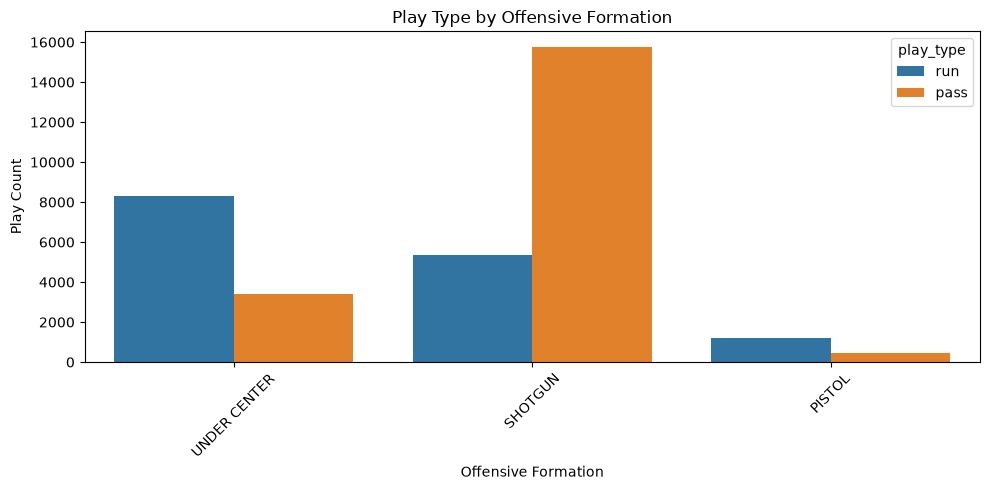

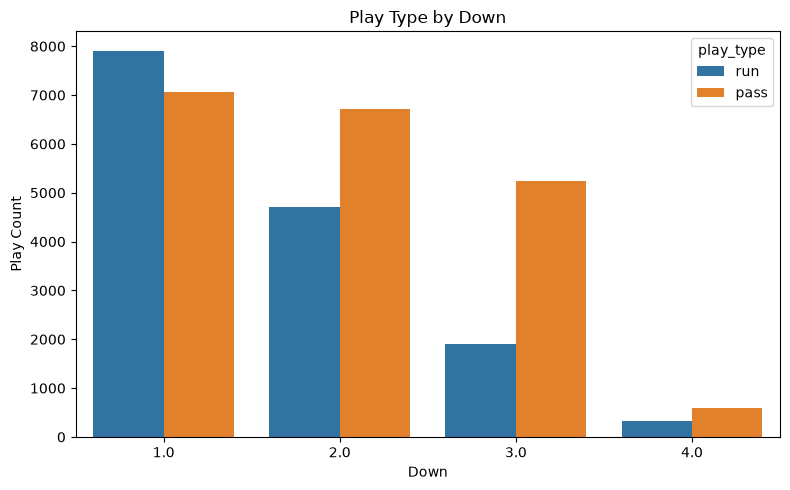

In [34]:
# Visualize the distribution of running and passing plays by offensive formation
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='offense_formation', hue='play_type')
plt.title('Play Type by Offensive Formation')
plt.xlabel('Offensive Formation')
plt.ylabel('Play Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize the distribution of running and passing plays by down number
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='down', hue='play_type')
plt.title('Play Type by Down')
plt.xlabel('Down')
plt.ylabel('Play Count')
plt.tight_layout()
plt.show()

## 5. Observations
- **UNDER CENTER** shows a strong tendency towards running plays, whereas **SHOTGUN** displays a greater proportion of passing plays. This suggests a strong predictive value of offensive formation alone.
- **3RD DOWN** has a significantly high proportion of passing plays as opposed to running plays. Alternatively, **1ST DOWN** shows a greater number of running plays than passing plays. This suggests that situational game context also has a strong influence on offesnive play calling.
- **11 PERSONNEL (1 RB, 1 TE, 3 WR)** makes up the majority of plays in the dataset, suggesting that due to its commonality in the modern NFL, formation and game context may be key distinguishers between play type where personnel packages have shortcomings.